# L5 companion 1 · Gradient-descent geometry and schedules

We will optimize

$$L(\theta)=(\theta-3)^2, \qquad \frac{dL}{d\theta}=2(\theta-3).$$

The goal is not merely to run an optimizer. For every experiment, **predict**, **calculate**, **run**, **inspect**, and **explain**.

By the end, you should be able to read a learning rate from the error multiplier $1-2\eta$ and anticipate crawl, convergence, oscillation, or divergence before plotting anything.

**Suggested timing with the lecture:** complete Sections 1–2 after the fixed-rate slides. Pause there, then return to Sections 3–4 after warmup and cosine decay have been introduced.

## 1 · Predict and calculate one update

Use $\theta_0=0$ and $\eta=0.1$. Before running the next cell, calculate:

1. the sign and value of $g_0$;
2. the sign and value of $\Delta\theta_0=-\eta g_0$;
3. $\theta_1$, $\theta_2$, and $\theta_3$.

Also say in words why a **negative** gradient produces a step to the **right** in this example.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

def loss(theta):
    return (theta - 3.0) ** 2

def grad(theta):
    return 2.0 * (theta - 3.0)

def run_gd(lr, steps=20, theta0=0.0, schedule=None):
    theta = float(theta0)
    rows = []
    for t in range(steps):
        eta_t = float(lr if schedule is None else schedule(t))
        g_t = grad(theta)
        rows.append((t, theta, loss(theta), g_t, eta_t, -eta_t * g_t))
        theta -= eta_t * g_t
    rows.append((steps, theta, loss(theta), grad(theta), np.nan, np.nan))
    return np.asarray(rows, dtype=float)

trace = run_gd(lr=0.1, steps=3)
print(" t   theta_t    L(theta_t)    g_t       delta_theta")
for t, theta, value, g_t, eta_t, delta in trace[:-1]:
    print(f"{int(t):2d}  {theta:8.4f}    {value:9.4f}  {g_t:8.4f}   {delta:10.4f}")
print("theta_1, theta_2, theta_3 =", trace[1:, 1])

assert np.allclose(trace[1:, 1], [0.6, 1.08, 1.464])

 t   theta_t    L(theta_t)    g_t       delta_theta
 0    0.0000       9.0000   -6.0000       0.6000
 1    0.6000       5.7600   -4.8000       0.4800
 2    1.0800       3.6864   -3.8400       0.3840
theta_1, theta_2, theta_3 = [0.6   1.08  1.464]


## 2 · Derive the error multiplier before simulating

Let $e_t=\theta_t-3$. Substitute the gradient into the update:

$$
e_{t+1}=\theta_{t+1}-3=(1-2\eta)(\theta_t-3)=(1-2\eta)e_t.
$$

Therefore $e_t=(1-2\eta)^t e_0$. The **sign** of $1-2\eta$ determines whether the trajectory alternates; its **magnitude** determines whether the error shrinks or grows.

Before running the next cell, complete this table for $\eta\in\{0.05,0.40,0.90,1.05\}$:

| $\eta$ | $1-2\eta$ | alternate? | shrink or grow? | prediction |
|---:|---:|:---:|:---:|:---|
| 0.05 | ? | ? | ? | ? |
| 0.40 | ? | ? | ? | ? |
| 0.90 | ? | ? | ? | ? |
| 1.05 | ? | ? | ? | ? |

In [2]:
rates = [0.05, 0.40, 0.90, 1.05]
print(" eta   multiplier   alternates   magnitude   behaviour")
for eta in rates:
    multiplier = 1 - 2 * eta
    alternates = multiplier < 0
    magnitude = abs(multiplier)
    if magnitude < 1:
        behaviour = "converges"
    elif magnitude == 1:
        behaviour = "does not settle"
    else:
        behaviour = "diverges"
    print(f"{eta:5.2f}    {multiplier:7.2f}       {str(alternates):5s}        {magnitude:5.2f}     {behaviour}")

assert all(np.isclose(run_gd(eta, steps=8)[-1, 1] - 3, (1 - 2*eta)**8 * (-3)) for eta in rates)

 eta   multiplier   alternates   magnitude   behaviour
 0.05       0.90       False         0.90     converges
 0.40       0.20       False         0.20     converges
 0.90      -0.80       True          0.80     converges
 1.05      -1.10       True          1.10     diverges


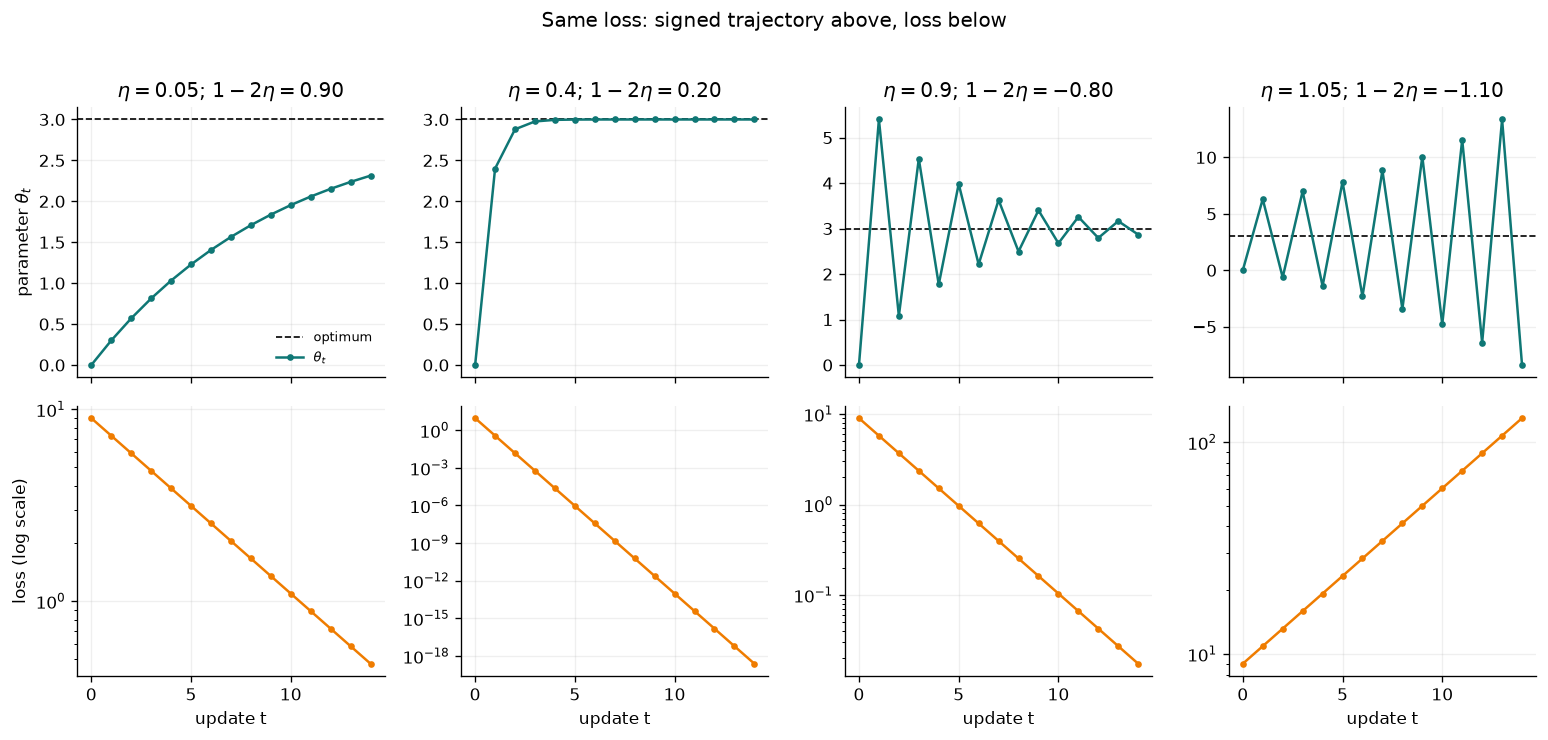

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(13, 6), sharex='col')
for col, eta in enumerate(rates):
    tr = run_gd(eta, steps=14)
    t = tr[:, 0]
    axes[0, col].axhline(3.0, color="black", lw=1, ls="--", label="optimum")
    axes[0, col].plot(t, tr[:, 1], "o-", color="#0f7775", ms=3, label=r"$\theta_t$")
    axes[0, col].set_title(fr"$\eta={eta}$; $1-2\eta={1-2*eta:.2f}$")
    axes[1, col].semilogy(t, np.maximum(tr[:, 2], 1e-30), "o-", color="#ef7c00", ms=3)
    axes[1, col].set_xlabel("update t")
    axes[0, col].grid(alpha=0.2)
    axes[1, col].grid(alpha=0.2)
axes[0, 0].set_ylabel(r"parameter $\theta_t$")
axes[1, 0].set_ylabel("loss (log scale)")
axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle("Same loss: signed trajectory above, loss below", y=1.02)
fig.tight_layout()
plt.show()

### Inspect and explain

For each panel, point to visible evidence for your prediction. Do not use only the word “fast” or “slow”: refer to the **sign** and **magnitude** of the multiplier.

Then answer: why is $\eta=0.9$ stable even though it overshoots the minimum on every step?

## 3 · A schedule changes the multiplier over time

A fixed learning rate uses the same error multiplier at every update. A schedule makes it time dependent:

$$e_{t+1}=(1-2\eta_t)e_t.
$$

We will compare a fixed rate with a short warmup followed by cosine decay. Update indices start at $t=0$; the first warmup rate is therefore $\eta_{0}=\eta_{\max}/T_w$, not zero. Here `total_steps = 60` means that rates $\eta_0,\ldots,\eta_{59}$ are applied. We also plot the boundary value $\eta_{60}=0$ to match the deck convention, but it is an **unexecuted endpoint**. Predict which run moves more slowly during the first five updates, and which run has the smaller late-stage oscillation.

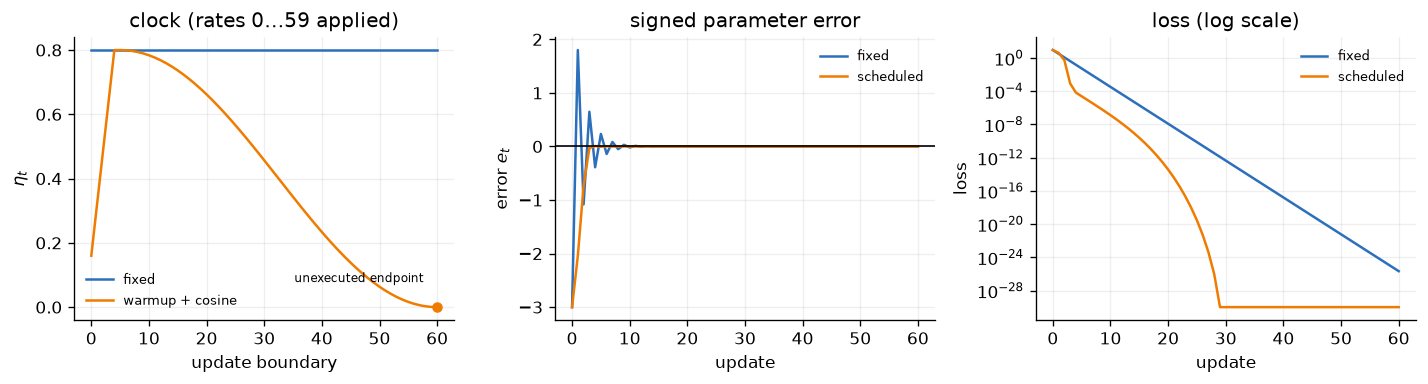

last applied rate eta_59 = 0.000652
unexecuted endpoint eta_60 = 0.000000


In [4]:
total_steps = 60
warmup_steps = 5
peak_lr = 0.8

def warmup_cosine(t):
    if t < warmup_steps:
        return peak_lr * (t + 1) / warmup_steps
    progress = (t - warmup_steps) / (total_steps - warmup_steps)
    return 0.5 * peak_lr * (1 + np.cos(np.pi * progress))

fixed = run_gd(lr=0.8, steps=total_steps)
scheduled = run_gd(lr=peak_lr, steps=total_steps, schedule=warmup_cosine)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.3))
clock_t = np.arange(total_steps + 1)  # includes the unexecuted boundary t=60
axes[0].plot(clock_t, np.full_like(clock_t, 0.8, dtype=float), label="fixed", color="#2c6fbb")
axes[0].plot(clock_t, [warmup_cosine(i) for i in clock_t], label="warmup + cosine", color="#ef7c00")
axes[0].scatter([total_steps], [warmup_cosine(total_steps)], color="#ef7c00", s=28, zorder=3)
axes[0].annotate("unexecuted endpoint", (total_steps, 0), xytext=(-8, 15), textcoords="offset points", ha="right", fontsize=7)
axes[0].set(xlabel="update boundary", ylabel=r"$\eta_t$", title="clock (rates 0…59 applied)")
axes[1].plot(fixed[:, 0], fixed[:, 1] - 3, label="fixed", color="#2c6fbb")
axes[1].plot(scheduled[:, 0], scheduled[:, 1] - 3, label="scheduled", color="#ef7c00")
axes[1].axhline(0, color="black", lw=1)
axes[1].set(xlabel="update", ylabel=r"error $e_t$", title="signed parameter error")
axes[2].semilogy(fixed[:, 0], np.maximum(fixed[:, 2], 1e-30), label="fixed", color="#2c6fbb")
axes[2].semilogy(scheduled[:, 0], np.maximum(scheduled[:, 2], 1e-30), label="scheduled", color="#ef7c00")
axes[2].set(xlabel="update", ylabel="loss", title="loss (log scale)")
for ax in axes:
    ax.grid(alpha=0.2)
    ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

print(f"last applied rate eta_59 = {warmup_cosine(total_steps - 1):.6f}")
print(f"unexecuted endpoint eta_60 = {warmup_cosine(total_steps):.6f}")
assert warmup_cosine(total_steps - 1) > 0
assert np.isclose(warmup_cosine(total_steps), 0.0)

## 4 · Explain, then change one thing

Write a short answer to each prompt:

1. Why does the fixed $\eta=0.8$ trajectory alternate?
2. How does cosine decay change the magnitude of the late-stage multiplier?
3. What would go wrong if the scheduler advanced once per **microbatch** while the optimizer stepped only once per four accumulated microbatches?
4. Change only `peak_lr` to `1.05`, just above the fixed-rate stability boundary. Identify the updates for which $|1-2\eta_t|>1$. Does the error grow transiently? Does later cosine decay allow it to recover within this finite run? Report both the maximum and final loss—do not summarize the result only as ‘diverges’ or ‘converges’.

### Takeaway

On a quadratic, the learning-rate story is completely visible in one number: $1-2\eta_t$. In larger networks we cannot reduce the dynamics to one multiplier, but the same habits remain valuable: predict the scale, inspect the path, and relate symptoms to the update rule.